## 0. Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
# general
from pathlib import Path

import geopandas as gpd

# for plotting and coloring
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

gpd.options.io_engine = "pyogrio"

In [3]:
from gridsample.utils import create_gmap_links, save_shapefiles, create_ids
# from gridsample.mapping import create_interactive_map

In [4]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_ifa"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
PROCESSED_DATA_DIR = DATA_DIR / "02. Processed Data"
OUTPUT_DATA_DIR = DATA_DIR / "03. Output Data"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

Need to also symlink the VIDA rooftop data folder inside Raw Data. MacOS:

    ln -s "/Users/amiremami/IDinsight Dropbox/Amir Emami/VIDA S2 Rooftop Data" "VIDA S2 Rooftop Data"

## 1. Load MapSolve boundaries

In [ ]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = (
    RAW_DATA_DIR / "Admin Boundaries" / "shrug-pc11subdist-poly-shp" / "subdistrict.shp"
)
gdf = gpd.read_file(boundaries_dir).to_crs(4326)

## 2. Load sampled subdistricts data

In [ ]:
# load the merged wards data
sample_df = pd.read_csv(RAW_DATA_DIR / "Admin Boundaries" / "UP_Bihar_Subdistricts.csv")

In [8]:
sample_df

,State,District,Subdistt,TOT_P,high_density
0,10,203,1014,249102.0,0
1,10,203,1015,208169.0,0
2,10,203,1016,190744.0,0
3,10,203,1017,377842.0,0
4,10,203,1019,398000.0,0
...,...,...,...,...,...
307,9,198,999,NaN,1
308,9,199,1000,NaN,1
309,9,199,1001,NaN,0
310,9,199,1002,NaN,0


### 2.1 Rename and clean both datasets

In [ ]:
gdf.rename(
    columns={
        "pc11_s_id": "state",
        "pc11_d_id": "district",
        "pc11_sd_id": "subdistrict",
        "sd_name": "subdistrict_name",
    },
    inplace=True,
)

In [10]:
sample_df.rename(
    columns={
        "State": "state",
        "District": "district",
        "Subdistt": "subdistrict",
        "TOT_P": "total_population",
    },
    inplace=True,
)

In [11]:
# make relevant codes into floats for both datasets
code_columns = [
    "state",
    "district",
    "subdistrict",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(int)
    gdf[col] = gdf[col].astype(int)

## 3. Filter boundaries to sampled areas

In [12]:
# filter based on state/district/subdistrict codes
filtered_gdf = gdf.merge(
    sample_df,
    on=["state", "district", "subdistrict"],
    how="inner",
)

In [13]:
filtered_gdf["state_name"] = filtered_gdf["state"].map(
    {
        10: "Bihar",
        9: "UP",
    }
)

In [14]:
filtered_gdf

,state,district,subdistrict,subdistrict_name,geometry,total_population,high_density,state_name
0,9,135,717,Thakurdwara,"POLYGON ((78.76152 29.26113, 78.76414 29.26109...",NaN,0,UP
1,9,135,718,Kanth,"MULTIPOLYGON (((78.72406 29.09949, 78.72378 29...",NaN,0,UP
2,9,135,719,Moradabad,"POLYGON ((78.97374 29.15127, 78.97444 29.15120...",NaN,1,UP
3,9,135,720,Bilari,"POLYGON ((78.70604 28.79828, 78.70677 28.79745...",NaN,1,UP
4,9,135,721,Sambhal,"POLYGON ((78.62103 28.80418, 78.62298 28.80306...",NaN,1,UP
...,...,...,...,...,...,...,...,...
307,10,238,1532,Khaira,"POLYGON ((86.18143 24.90653, 86.18191 24.90650...",235761.0,0,Bihar
308,10,238,1534,Chakai,"POLYGON ((86.49264 24.70085, 86.49362 24.70061...",235188.0,0,Bihar
309,10,239,1535,Ratni Faridpur,"POLYGON ((84.89004 25.25375, 84.89035 25.25374...",146586.0,0,Bihar
310,10,239,1540,Makhdumpur,"POLYGON ((85.07797 25.15016, 85.07815 25.14854...",260154.0,0,Bihar


In [ ]:
set(filtered_gdf["subdistrict"].unique()).difference(
    set(sample_df["subdistrict"].unique())
)

set()

In [ ]:
set(sample_df["subdistrict"].unique()).difference(
    set(filtered_gdf["subdistrict"].unique())
)

set()

<Axes: >

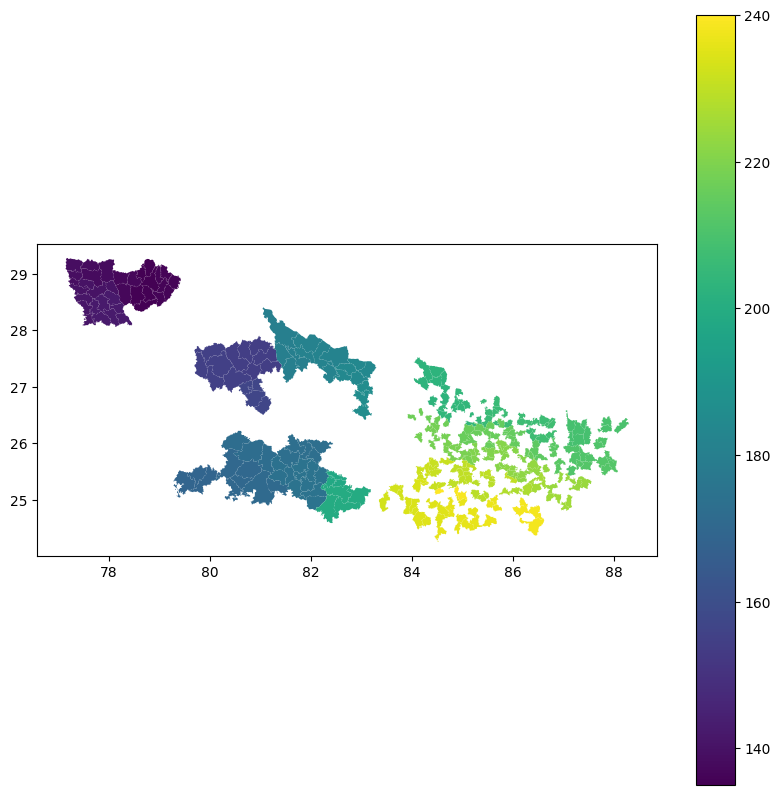

In [17]:
filtered_gdf.plot(column="district", figsize=(10, 10), legend=True)

## 5. Download rooftops

#### Identify S2 cell IDs

Shapes with spillover after round 1: 7


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:127: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


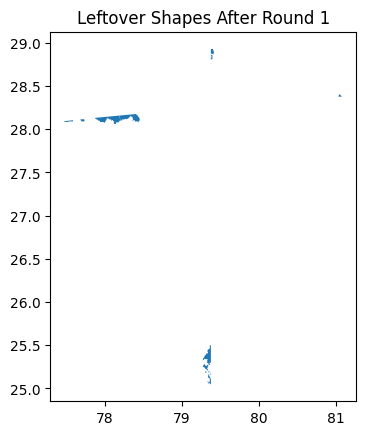

Shapes with spillover after round 2: 2


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


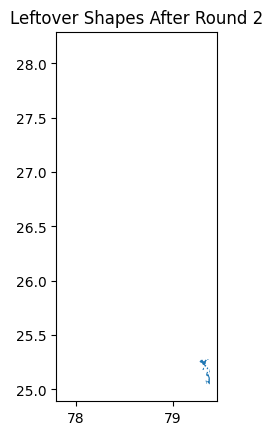

Shapes with spillover after round 3: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


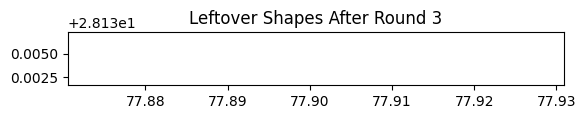

Shapes with spillover after round 4: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


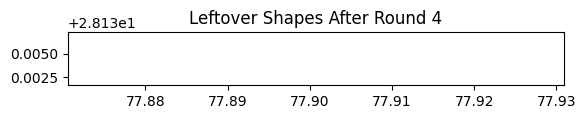

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 5: 1


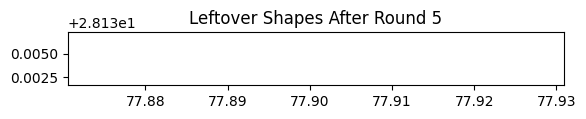

Shapes with spillover after round 6: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


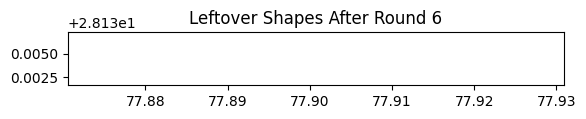

Shapes with spillover after round 7: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


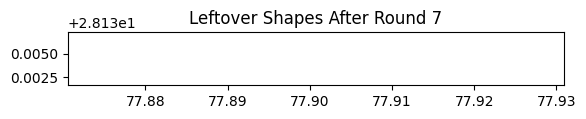

Shapes with spillover after round 8: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


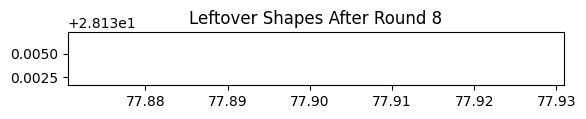

Shapes with spillover after round 9: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


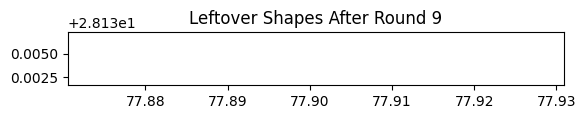

Shapes with spillover after round 10: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


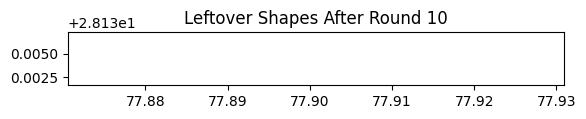

Shapes with spillover after round 11: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


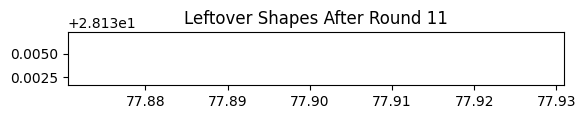

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 12: 1


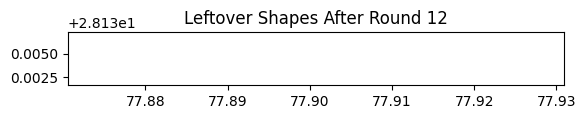

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 13: 1


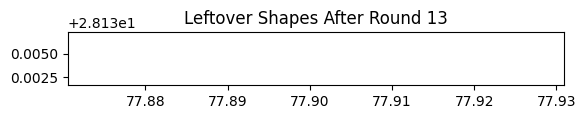

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 14: 1


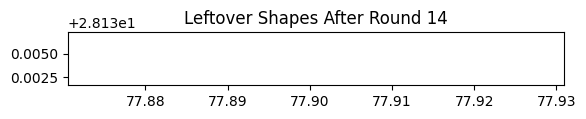

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 15: 1


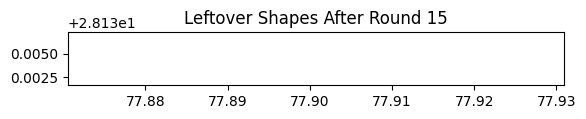

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 16: 1


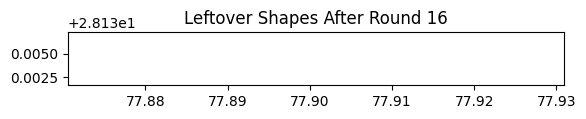

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 17: 1


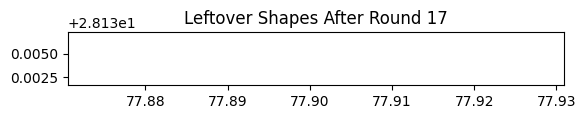

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 18: 1


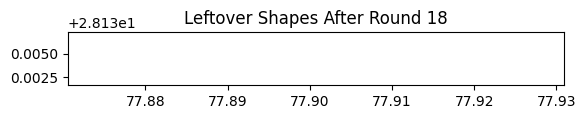

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 19: 1


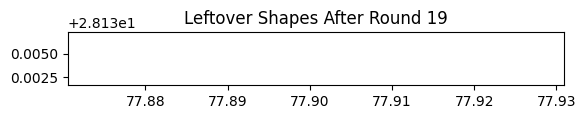

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 20: 1


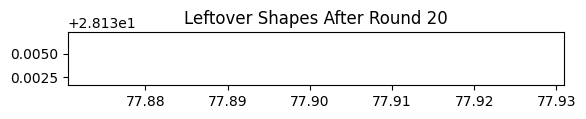

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 21: 1


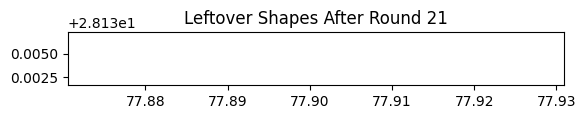

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 22: 1


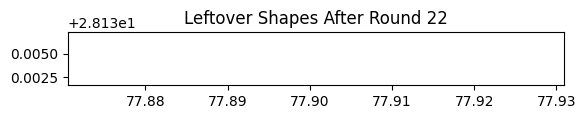

Shapes with spillover after round 23: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


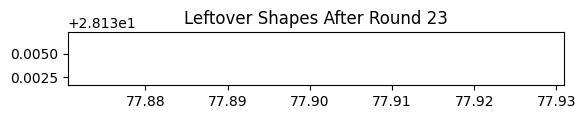

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 24: 1


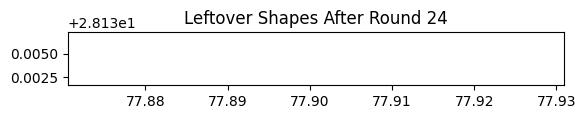

Shapes with spillover after round 25: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


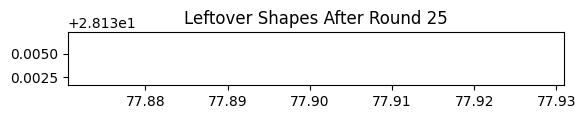

Shapes with spillover after round 26: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


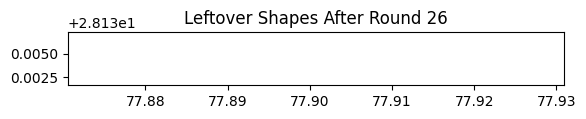

Shapes with spillover after round 27: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


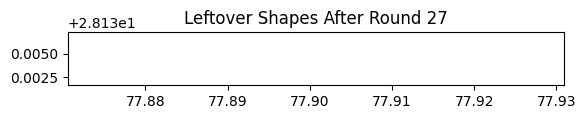

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 28: 1


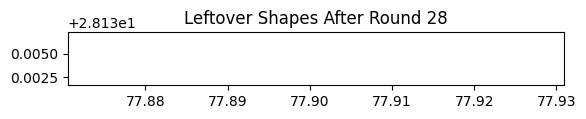

Shapes with spillover after round 29: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


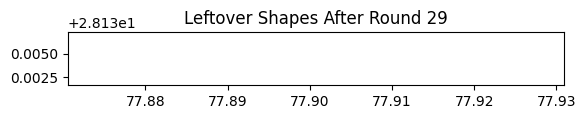

Shapes with spillover after round 30: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


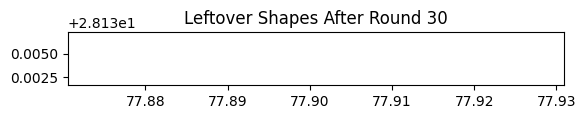

Shapes with spillover after round 31: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


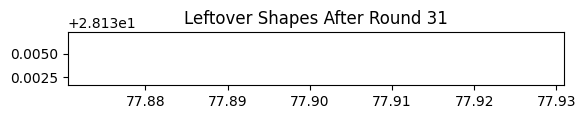

Shapes with spillover after round 32: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


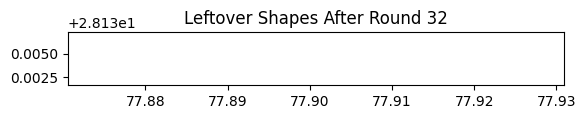

Shapes with spillover after round 33: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


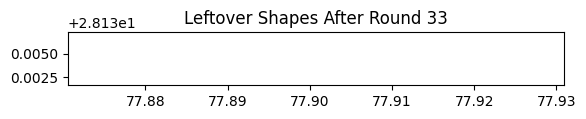

Shapes with spillover after round 34: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


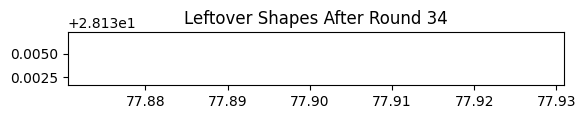

Shapes with spillover after round 35: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


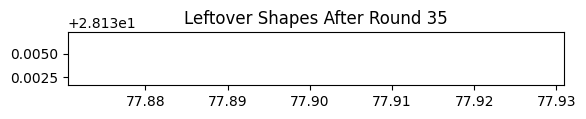

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 36: 1


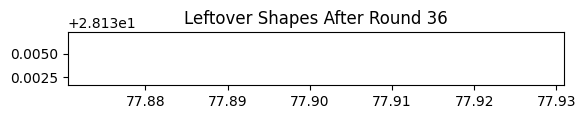

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 37: 1


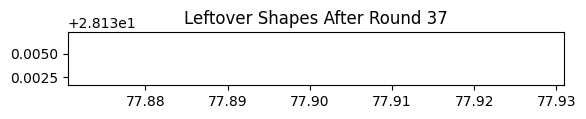

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 38: 1


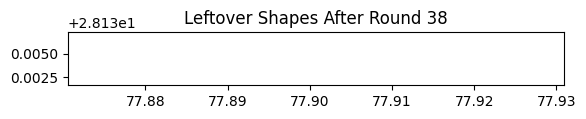

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 39: 1


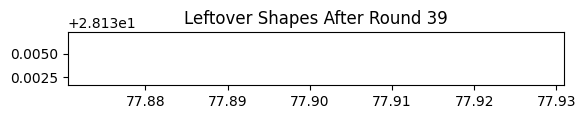

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 40: 1


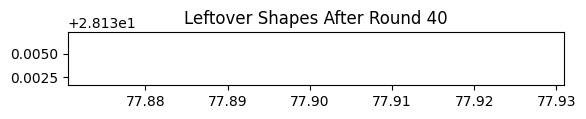

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 41: 1


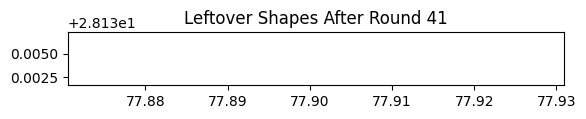

Shapes with spillover after round 42: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


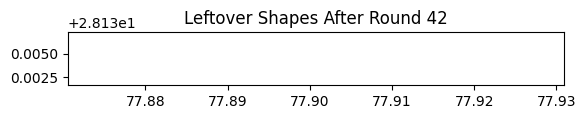

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 43: 1


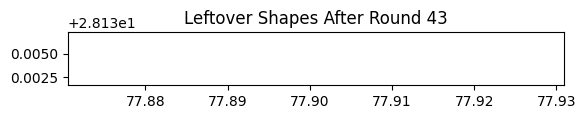

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 44: 1


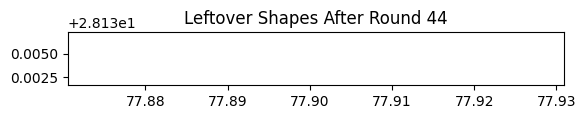

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 45: 1


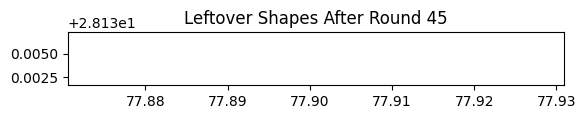

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 46: 1


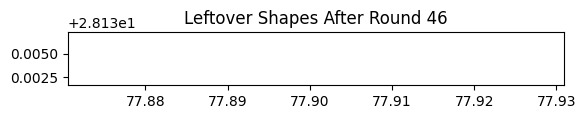

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 47: 1


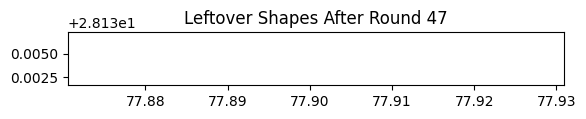

Shapes with spillover after round 48: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


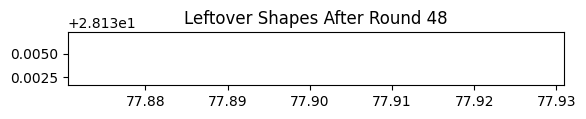

Shapes with spillover after round 49: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


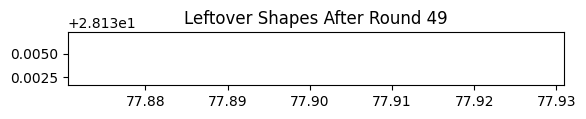

Shapes with spillover after round 50: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


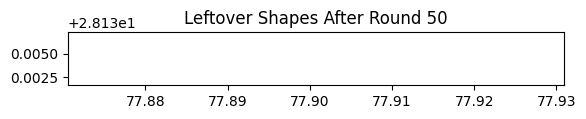

Shapes with spillover after round 51: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


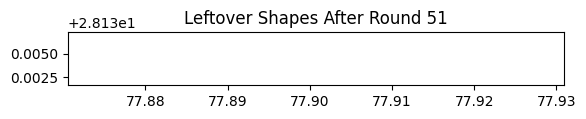

Shapes with spillover after round 52: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


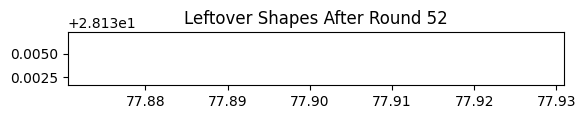

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 53: 1


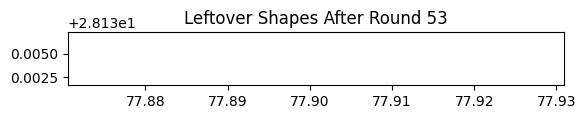

Shapes with spillover after round 54: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


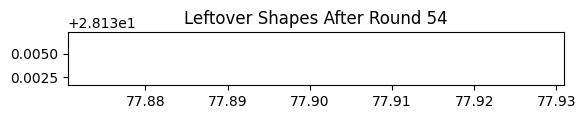

Shapes with spillover after round 55: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


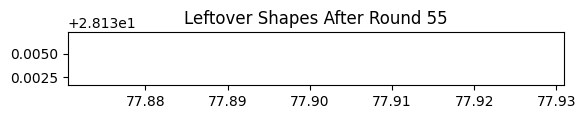

Shapes with spillover after round 56: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


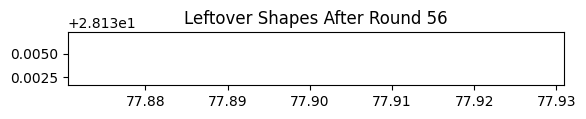

Shapes with spillover after round 57: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


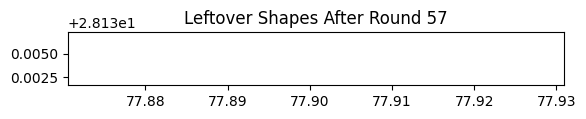

Shapes with spillover after round 58: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


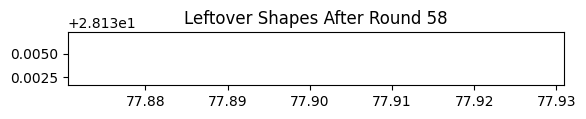

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 59: 1


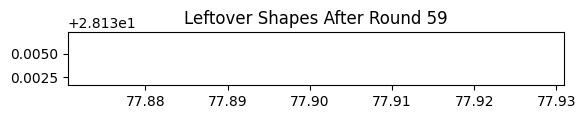

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 60: 1


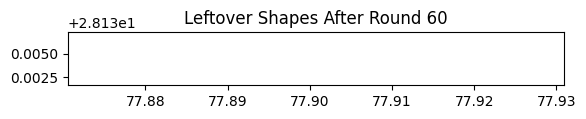

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 61: 1


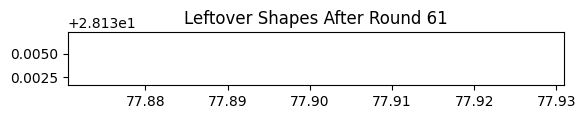

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 62: 1


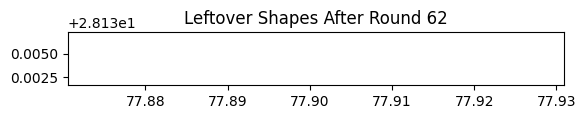

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 63: 1


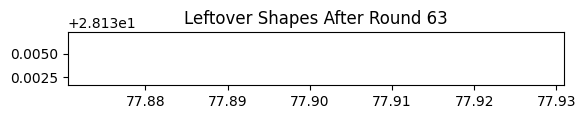

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 64: 1


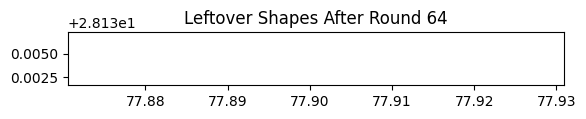

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 65: 1


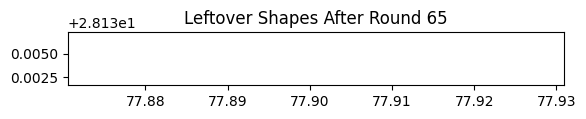

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 66: 1


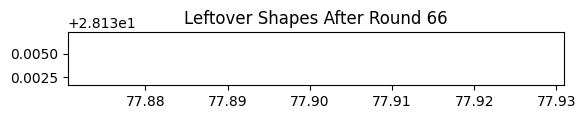

Shapes with spillover after round 67: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


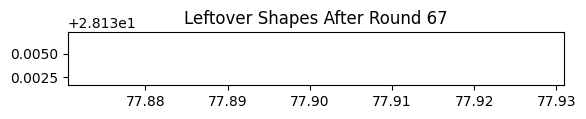

Shapes with spillover after round 68: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


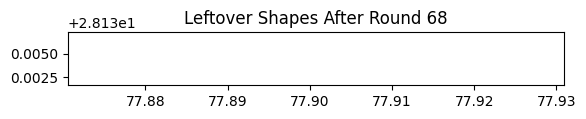

Shapes with spillover after round 69: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


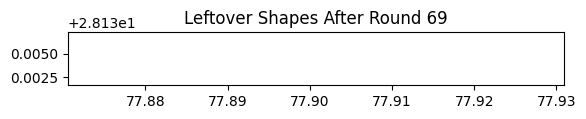

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 70: 1


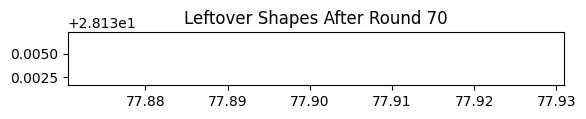

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 71: 1


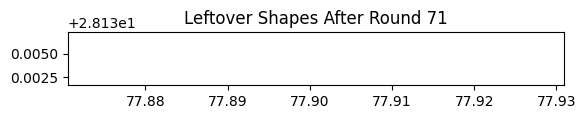

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 72: 1


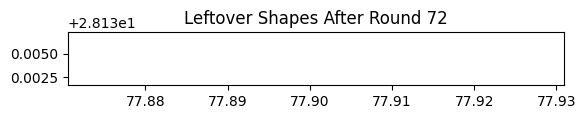

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 73: 1


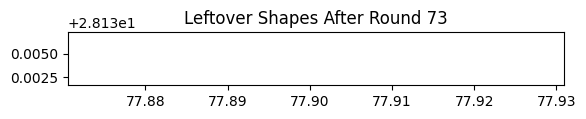

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 74: 1


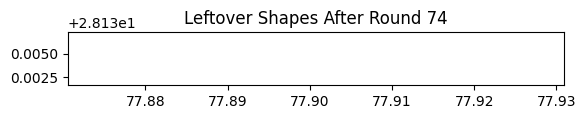

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 75: 1


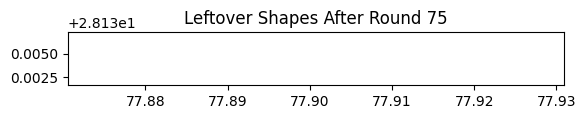

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 76: 1


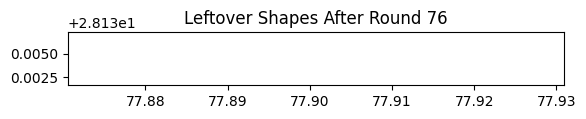

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 77: 1


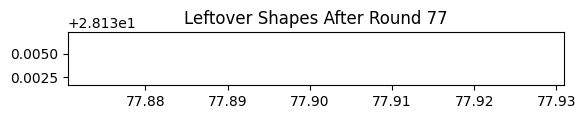

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 78: 1


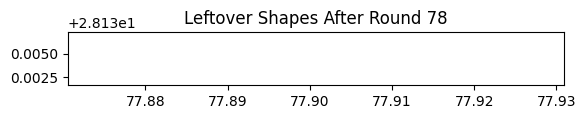

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 79: 1


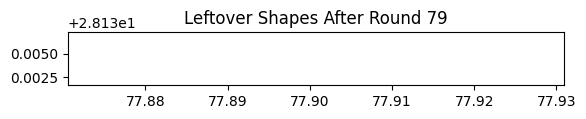

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 80: 1


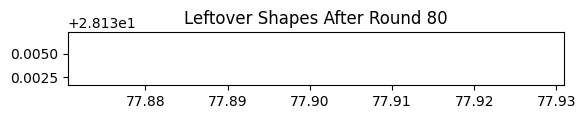

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 81: 1


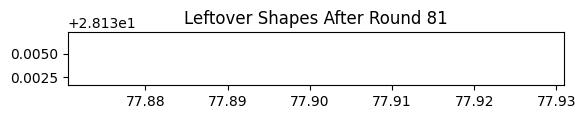

Shapes with spillover after round 82: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


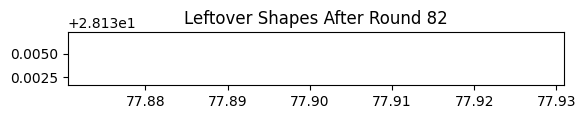

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 83: 1


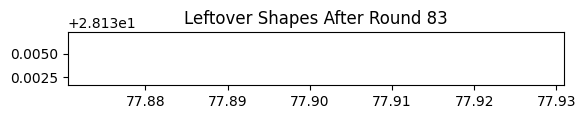

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 84: 1


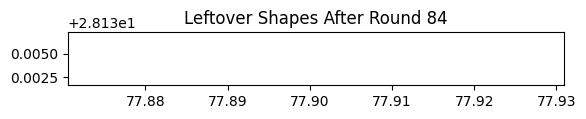

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 85: 1


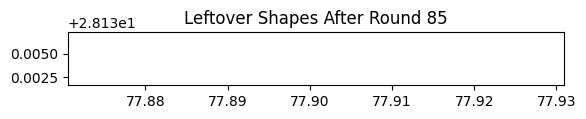

/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 86: 1


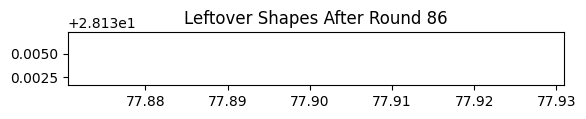

Shapes with spillover after round 87: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


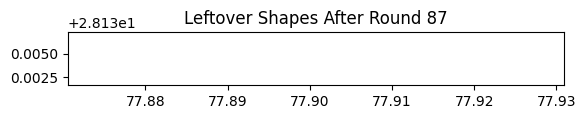

Shapes with spillover after round 88: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


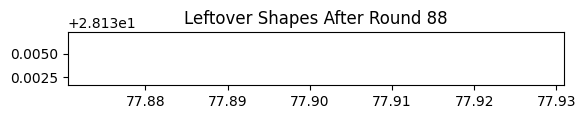

Shapes with spillover after round 89: 1


/Users/amiremami/IDinsight Repos/rooftop_sampling/up_bihar/utils.py:143: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


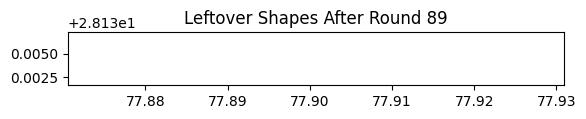

In [ ]:
s2_cell_ids = get_s2_cell_ids(filtered_gdf)
len(s2_cell_ids)

#### Check if identified cells cover all areas of interest

In [ ]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [ ]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = filtered_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

In [ ]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
filtered_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [ ]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        filtered_gdf[["state_name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [ ]:
# note: this will have duplicate s2 cell rows with different states if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

#### Download the S2 cells

In [ ]:
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids, "IND", RAW_DATA_DIR / "VIDA S2 Rooftop Data" / "Available"
)

## 6. Load rooftops and match to areas

In [ ]:
state_names = filtered_gdf["state_name"].sort_values().unique()

In [ ]:
for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["state_name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = filtered_gdf[filtered_gdf["state_name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_file_dir=RAW_DATA_DIR / "VIDA S2 Rooftop Data" / "Available",
            s2_cell_id=s2_cell_id,
            boundaries_gdf=gdf_subset,
        )
        matched_rooftop_centroids_gdf.drop(
            columns=[
                "boundary_id",
                "bf_source",
                "confidence",
                "area_in_meters",
                "s2_id",
                "country_iso",
                "geohash",
                "bbox",
            ],
            inplace=True,
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["state_name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        PROCESSED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

In [ ]:
# ax = matched_rooftop_centroids_gdf.sample(1000).plot(
#     cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
# )
# gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [ ]:
matched_rooftop_dir = PROCESSED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# filter to those that have selected_states in the name
all_filepaths = [
    f for f in all_filepaths if any(state in f.parent.name for state in state_names)
]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

In [ ]:
len(matched_rooftops_gdf)

In [ ]:
matched_rooftops_gdf["overall_rooftop_id"] = create_ids(
    len(matched_rooftops_gdf), prefix="rooftop_"
)

In [ ]:
no_rooftop_subdistrict_IDs = set(
    filtered_gdf[filtered_gdf["state"].isin(state_names)]["subdistrict"].unique()
).difference(set(matched_rooftops_gdf["subdistrict"].unique()))
no_rooftop_subdistrict_gdf = filtered_gdf[
    filtered_gdf["subdistrict"].isin(no_rooftop_subdistrict_IDs)
]
no_rooftop_subdistrict_gdf

In [ ]:
if len(no_rooftop_subdistrict_gdf) > 0:
    print("Saving subdistricts with no rooftops...")
    save_shapefiles(
        no_rooftop_subdistrict_gdf,
        OUTPUT_DATA_DIR / "Sampled Subdistricts",
        "subdistricts_with_no_rooftops",
        ["csv", "kml"],
    )

## 8. Sample rooftops

In [ ]:
# Define the base number of rooftops per ward by state
ROOFTOPS_PER_SUBDISTRICT = {
    "UP": 21,  # UP
    "Bihar": 11,  # Bihar
}

# Sample rooftops, multiplying by Ward Count for each PSU.
sampled_rooftops_gdf = matched_rooftops_gdf.groupby(
    "subdistrict", group_keys=False
).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_SUBDISTRICT[x["state_name"].iloc[0]], x.shape[0]),
        random_state=42,
    )
)

In [ ]:
# sampled_rooftops_gdf.groupby(["state_name", "subdistrict"]).size()

In [ ]:
print("Length of matched_rooftops_gdf:", len(matched_rooftops_gdf))
print("Length of sampled rooftops:", len(sampled_rooftops_gdf))

In [ ]:
sampled_rooftops_gdf.plot(
    figsize=(8, 8),
    column="state_name",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [ ]:
# Rooftop number within each subdistrict
sampled_rooftops_gdf["Rooftop Subdistrict ID Numeric"] = (
    sampled_rooftops_gdf.groupby("subdistrict").cumcount() + 1
)

## Find nearest neighbour replacement pins

Using efficient KD-tree algorithm to find 20 nearest rooftops for each sampled rooftop.

In [ ]:
from utils import find_k_nearest_rooftops

In [ ]:
# Example usage: Find 20 nearest rooftops for each sampled rooftop
# Note: Adjust the variable names based on what you have in your notebook

# Find k=20 nearest neighbours
neighbours_df = find_k_nearest_rooftops(
    all_rooftops_gdf=matched_rooftops_gdf[
        matched_rooftops_gdf["high_density"] == 0
    ],  # All rural rooftops
    sampled_rooftops_gdf=sampled_rooftops_gdf[
        sampled_rooftops_gdf["high_density"] == 0
    ],  # sampled rural rooftops
    k=20,
    max_distance_m=2000,  # Optional: only include neighbours within 2km
)

# Display results
print(f"\nTotal neighbour relationships: {len(neighbours_df):,}")
print(
    f"Average neighbours per sample: {len(neighbours_df) / len(sampled_rooftops_gdf[
        sampled_rooftops_gdf["high_density"] == 0
    ]):.1f}"
)
neighbours_df.head(25)

In [ ]:
neighbours_df

In [ ]:
# filter neighbours to only those that are NOT also in the sampled rooftops
neighbours_df = neighbours_df[
    ~neighbours_df["neighbour_idx"].isin(neighbours_df["sampled_idx"].unique())
]
# drop second instances of a neighbour belonging to multiple sampled rooftops
neighbours_df = neighbours_df.drop_duplicates(subset=["neighbour_idx"])

In [ ]:
neighbours_df

In [ ]:
# Visualize distance distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance distribution
axes[0].hist(neighbours_df["Distance from Original (m)"], bins=50, edgecolor="black")
axes[0].set_xlabel("Distance (meters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Neighbour Distances")
axes[0].grid(True, alpha=0.3)

# Distance by rank
neighbours_df.boxplot(
    column="Distance from Original (m)", by="Neighbour Rank", ax=axes[1]
)
axes[1].set_xlabel("Neighbour Rank")
axes[1].set_ylabel("Distance (meters)")
axes[1].set_title("Distance by Neighbour Rank")
axes[1].grid(True, alpha=0.3)
plt.suptitle("")  # Remove auto-generated title

plt.tight_layout()
plt.show()

In [ ]:
# add metadata for all neighbours
neighbours_with_details = neighbours_df.merge(
    matched_rooftops_gdf,
    left_on="neighbour_idx",
    right_index=True,
    how="left",
)
neighbours_with_details.head()

In [ ]:
# add original rooftop IDs for neighbours
neighbours_with_details = neighbours_with_details.merge(
    matched_rooftops_gdf["overall_rooftop_id"],
    left_on="sampled_idx",
    right_index=True,
    how="left",
    suffixes=("", "_original"),
)
neighbours_with_details.head()

In [ ]:
neighbours_with_details.isna().sum()

In [ ]:
set(neighbours_with_details["overall_rooftop_id_original"].unique()).difference(
    set(sampled_rooftops_gdf["overall_rooftop_id"].unique())
)

In [ ]:
# add Rooftop Subdistrict ID based on matching overall_rooftop_id_original
neighbours_with_details["Rooftop Subdistrict ID Numeric"] = neighbours_with_details[
    "overall_rooftop_id_original"
].map(
    sampled_rooftops_gdf.set_index("overall_rooftop_id")[
        "Rooftop Subdistrict ID Numeric"
    ]
)

In [ ]:
neighbours_with_details.isna().sum()

### Add the navigation pins to the sampled set

Update rural pins to have IDs like `PIN_1_1, PIN_2_1, ...` and then label the neighbours of `PIN_1_1` as `PIN_1_2, PIN_1_3, ...`

In [ ]:
sampled_rooftops_gdf["Neighbour Rank"] = 0
sampled_rooftops_gdf["Distance from Original (m)"] = 0

In [ ]:
# order columns to match sampled_rooftops_gdf
neighbours_final = neighbours_with_details[sampled_rooftops_gdf.columns]

In [ ]:
combined_sampled_and_neighbours_gdf = pd.concat(
    [sampled_rooftops_gdf, neighbours_final], ignore_index=True
)
combined_sampled_and_neighbours_gdf["Distance from Original (m)"] = (
    combined_sampled_and_neighbours_gdf["Distance from Original (m)"].round(2)
)

In [ ]:
sorted_sampled_and_neighbours_gdf = combined_sampled_and_neighbours_gdf.sort_values(
    by=[
        "state_name",
        "subdistrict",
        "Rooftop Subdistrict ID Numeric",
        "Neighbour Rank",
    ],
    ignore_index=True,
)


In [ ]:
sorted_sampled_and_neighbours_gdf

In [ ]:
# Make unique Pin IDs
sorted_sampled_and_neighbours_gdf.loc[
    sorted_sampled_and_neighbours_gdf["high_density"] == 1, "Pin ID"
] = "PIN_" + sorted_sampled_and_neighbours_gdf["Rooftop Subdistrict ID Numeric"].astype(
    str
)
sorted_sampled_and_neighbours_gdf.loc[
    sorted_sampled_and_neighbours_gdf["high_density"] == 0, "Pin ID"
] = (
    "PIN_"
    + sorted_sampled_and_neighbours_gdf["Rooftop Subdistrict ID Numeric"].astype(str)
    + "_"
    + sorted_sampled_and_neighbours_gdf["Neighbour Rank"].astype(str)
)

In [ ]:
sorted_sampled_and_neighbours_gdf

In [ ]:
sorted_sampled_and_neighbours_gdf.isna().sum()

In [ ]:
# Rooftop Unique ID
sorted_sampled_and_neighbours_gdf["Rooftop Unique ID"] = (
    sorted_sampled_and_neighbours_gdf.apply(
        lambda row: f"state_{row['state_name']}_subd_{row['subdistrict']}_rooftop_{row['Pin ID']}",
        axis=1,
    )
)

In [ ]:
sampled_rooftops_gdf_old = sampled_rooftops_gdf.copy()
sampled_rooftops_gdf = sorted_sampled_and_neighbours_gdf.copy()

### Add gmap link

In [ ]:
sampled_rooftops_gdf["latitude_original"] = sampled_rooftops_gdf.geometry.y
sampled_rooftops_gdf["longitude_original"] = sampled_rooftops_gdf.geometry.x
sampled_rooftops_gdf["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops_gdf,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

In [ ]:
sampled_rooftops_gdf.columns

In [ ]:
chosen_cols = [
    # IDs
    "Pin ID",
    "Rooftop Subdistrict ID Numeric",
    "Neighbour Rank",
    "Rooftop Unique ID",
    "overall_rooftop_id",
    # Admin
    "state_name",
    "state",
    "district",
    "subdistrict",
    "subdistrict_name",
    "high_density",
    "total_population",
    # Location
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    # Geometry
    "geometry",
]

In [ ]:
sampled_rooftops_gdf = sampled_rooftops_gdf[chosen_cols]

In [ ]:
sampled_rooftops_gdf

### Save sampled data (original rooftop pins)

In [ ]:
def save_partitioned_kmls(gdf, FOLDER_PATH, filename_prefix):
    """
    Save the sampled rooftops GeoDataFrame into multiple KML files,
    each containing a maximum of 1500 rows.
    """
    MAX_ROWS_PER_FILE = 1500
    n_partitions = (len(gdf) + MAX_ROWS_PER_FILE - 1) // MAX_ROWS_PER_FILE

    for partition_idx in range(n_partitions):
        start_idx = partition_idx * MAX_ROWS_PER_FILE
        end_idx = min((partition_idx + 1) * MAX_ROWS_PER_FILE, len(gdf))

        partition_gdf = gdf.iloc[start_idx:end_idx]

        save_shapefiles(
            partition_gdf,
            FOLDER_PATH,
            f"{filename_prefix}_part_{partition_idx + 1}",
            ["kml"],
        )

In [ ]:
save_shapefiles(
    sampled_rooftops_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet"],
)

save_partitioned_kmls(
    sampled_rooftops_gdf.drop(columns=["gmap_link_original"]),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample KMLs",
    "sampled_rooftops_centroids_original",
)

#### DONE

Navigation pins:
- Match to orginal sample ID and 
- add new rooftop IDs to the neighbours 
- and insert them into the main sample


IDs:
- Pin numbering per subdistrict, 1, 2, 3, ...
- In rural, 1_1, 1_2, 1_3, ...

#### TO DO
Output files:
- Across all - slices of original then every 5 nav pins
- Per district, all?

## 9. Snap points to road

In [ ]:
import yaml
from shapely import Point

from utils import (
    get_nearest_points_on_road_batch,
    get_nearest_points_on_road_batch_parallel,
)

In [ ]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [ ]:
get_nearest_points_on_road_batch(
    [Point(77.11432151622034, 28.677391409999522)], api_key
)

In [ ]:
# test
get_nearest_points_on_road_batch(sampled_rooftops_gdf.geometry.iloc[:5], api_key)

In [ ]:
get_nearest_points_on_road_batch_parallel(sampled_rooftops_gdf.iloc[:150], api_key)

#### Snap points to road

In [ ]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = (
    sampled_rooftops_snapped_gdf.index.map(snapped_points_series)
)

In [ ]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

#### Replace geometry to snapped one (missing filled in with original)

In [ ]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [ ]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

#### Update lat, lon, gmap_link

In [ ]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Make lines between original and snapped points

In [ ]:
from shapely.geometry import LineString

In [ ]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [ ]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

#### Save new files: snapped points, snapped lines

In [ ]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [ ]:
# Save KML
# save_shapefiles(
#     sampled_rooftops_snapped_gdf.drop(
#         columns=[
#             "geometry_original",
#             "geometry_line",
#             # bad cols for KML
#             "gmap_link_original",
#             "gmap_link"
#         ]
#     ),
#     OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
#     "sampled_rooftops_snapped_points",
#     ["kml"],
# )

save_partitioned_kmls(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample KMLs",
    "sampled_rooftops_snapped_points",
)

In [ ]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

In [ ]:
save_shapefiles(
    sampled_rooftops_line_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["parquet"],
)

save_partitioned_kmls(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample KMLs",
    "sampled_rooftops_snapped_lines",
)

## Save per state and district

In [ ]:
for state in tqdm(sampled_rooftops_gdf["state_name"].unique()):
    state_output_folder = (
        OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "By State" / state
    )

    # save original points
    selected_state_original_gdf = sampled_rooftops_gdf[
        sampled_rooftops_gdf["state_name"] == state
    ]

    save_shapefiles(
        selected_state_original_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    # save_shapefiles(
    #     selected_state_original_gdf.drop(
    #         # drop kml unfriendly columns
    #         columns=["gmap_link_original"]
    #     ),
    #     state_output_folder,
    #     f"{state}_sampled_rooftops_centroids_original",
    #     ["kml"],
    # )
    save_partitioned_kmls(
        selected_state_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        state_output_folder / "KMLs",
        f"{state}_sampled_rooftops_centroids_original",
    )

    # Save snapped points
    selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["state_name"] == state
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_state_snapped_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    # save_shapefiles(
    #     selected_state_snapped_gdf.drop(
    #         # drop kml unfriendly columns
    #         columns=["gmap_link_original", "gmap_link"]
    #     ),
    #     state_output_folder,
    #     f"{state}_sampled_rooftops_snapped_points",
    #     ["kml"],
    # )
    save_partitioned_kmls(
        selected_state_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder / "KMLs",
        f"{state}_sampled_rooftops_snapped_points",
    )

    # Save lines
    selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["state_name"] == state
    ]
    save_shapefiles(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["parquet"],
    )
    # save_shapefiles(
    #     selected_state_sampled_rooftops_line_gdf.drop(
    #         # drop kml unfriendly columns
    #         columns=["gmap_link_original", "gmap_link"]
    #     ),
    #     state_output_folder,
    #     f"{state}_sampled_rooftops_snapped_lines",
    #     ["kml"],
    # )
    save_partitioned_kmls(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder / "KMLs",
        f"{state}_sampled_rooftops_snapped_lines",
    )

### Save slices per state

In [ ]:
# from math import ceil
# SLICE_SIZE = 25
# N_SLICES = ceil(ROOFTOPS_PER_SUBDISTRICT / SLICE_SIZE)

# print(f"ROOFTOPS_PER_SUBDISTRICT: {ROOFTOPS_PER_SUBDISTRICT}")
# print(f"SLICE_SIZE: {SLICE_SIZE}")
# print(f"N_SLICES: {N_SLICES}")
# print(f"N_SLICES * SLICE_SIZE: {N_SLICES * SLICE_SIZE}")

In [ ]:
# sampled_rooftops_gdf["state"].unique()

In [ ]:
# for state in tqdm(sampled_rooftops_gdf["state"].unique()):
#     state_gdf = sampled_rooftops_gdf[
#         sampled_rooftops_gdf["state"] == state
#     ]
#     for slice_idx in range(N_SLICES):

#         original_points_slice_rows = []
#         snapped_points_slice_rows = []
#         line_slice_rows = []

#         for psu_id, psu_df in state_gdf.groupby("subdistrict"):
#             # get counts and indices from the original dataframe (also applies to the other two)
#             ward_count = int(psu_df["Ward Count"].iloc[0])
#             start_idx = slice_idx * SLICE_SIZE * ward_count
#             end_idx = start_idx + (SLICE_SIZE * ward_count)

#             # original points
#             psu_original_slice = sampled_rooftops_gdf[
#                 (sampled_rooftops_gdf["state"] == state)
#                 & (sampled_rooftops_gdf["subdistrict"] == psu_id)
#             ].iloc[start_idx:end_idx]
#             original_points_slice_rows.append(psu_original_slice)

#             # snapped points
#             psu_snapped_slice = sampled_rooftops_snapped_gdf[
#                 (sampled_rooftops_snapped_gdf["state"] == state)
#                 & (sampled_rooftops_snapped_gdf["subdistrict"] == psu_id)
#             ].iloc[start_idx:end_idx]
#             snapped_points_slice_rows.append(psu_snapped_slice)

#             # lines
#             psu_line_slice = sampled_rooftops_line_gdf[
#                 (sampled_rooftops_line_gdf["state"] == state)
#                 & (sampled_rooftops_line_gdf["subdistrict"] == psu_id)
#             ].iloc[start_idx:end_idx]
#             line_slice_rows.append(psu_line_slice)


#         # Concatenate all PSU slices for this state and slice
#         state_slice_original_gdf = pd.concat(original_points_slice_rows, ignore_index=True)
#         state_slice_snapped_gdf = pd.concat(snapped_points_slice_rows, ignore_index=True)
#         state_slice_line_gdf = pd.concat(line_slice_rows, ignore_index=True)

#         # set folder
#         state_slice_output_folder = (
#             OUTPUT_DATA_DIR
#             / "01. Sampled Rooftop Data"
#             / state
#             / f"slice_{slice_idx}"
#         )

#         # Save original points
#         save_shapefiles(
#             state_slice_original_gdf,
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
#             ["csv", "parquet"],
#         )
#         save_shapefiles(
#             state_slice_original_gdf.drop(columns=["gmap_link_original"]),
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
#             ["kml"],
#         )

#         # Save snapped points
#         save_shapefiles(
#             state_slice_snapped_gdf,
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
#             ["csv", "parquet"],
#         )
#         save_shapefiles(
#             state_slice_snapped_gdf.drop(
#                 # drop kml unfriendly columns
#                 columns=["gmap_link_original", "gmap_link", "geometry_line", "geometry_original"]
#             ),
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
#             ["kml"],
#         )

#         # Save lines
#         save_shapefiles(
#             state_slice_line_gdf.drop(
#                 # drop kml unfriendly columns
#                 columns=["gmap_link_original", "gmap_link"]
#             ),
#             state_slice_output_folder,
#             f"{state}_sampled_rooftops_snapped_lines_{slice_idx}",
#             ["parquet", "kml"],
#         )

<!-- ## Save per-PSU -->

In [ ]:
# for psu_id in tqdm(sampled_rooftops_gdf["subdistrict"].unique()):

#     # save original points
#     selected_psu_original_gdf = sampled_rooftops_gdf[
#         sampled_rooftops_gdf["subdistrict"] == psu_id
#     ]

#     # for folder name
#     first_row = selected_psu_original_gdf.iloc[0]
#     psu_type = first_row["PSU Type"]
#     state_name = first_row["state"].strip().replace(" ", "_")
#     district_name = first_row["District Name"].strip().replace(" ", "_")
#     subdistrict_name = first_row["Subdistrict Name"].strip().replace(" ", "_")
#     tv_code = int(first_row["TV Code"]) if pd.notna(first_row["TV Code"]) else None
#     ward_code = int(first_row["Ward Code"]) if pd.notna(first_row["Ward Code"]) else None

#     if psu_type == "ward":
#         foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_WARD_{ward_code}_PSUID_{psu_id}"
#     elif psu_type == "town_village":
#         foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_PSUID_{psu_id}"
#     elif psu_type == "subdistrict":
#         foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_PSUID_{psu_id}"
#     else:
#         raise ValueError(f"Unknown PSU Type: {psu_type}")
#     psu_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "PSU-Level" / foldername
#     psu_output_folder.mkdir(parents=True, exist_ok=True)

#     save_shapefiles(
#         selected_psu_original_gdf,
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_centroids_original",
#         ["csv", "parquet"],
#     )
#     save_shapefiles(
#         selected_psu_original_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original"]
#         ),
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_centroids_original",
#         ["kml"],
#     )

#     # Save snapped points
#     selected_psu_snapped_gdf = sampled_rooftops_snapped_gdf[
#         sampled_rooftops_snapped_gdf["subdistrict"] == psu_id
#     ].drop(
#         columns=[
#             "geometry_original",
#             "geometry_line",
#         ]
#     )
#     save_shapefiles(
#         selected_psu_snapped_gdf,
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_snapped_points",
#         ["csv", "parquet"],
#     )
#     save_shapefiles(
#         selected_psu_snapped_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_snapped_points",
#         ["kml"],
#     )

#     # Save lines
#     selected_psu_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
#         sampled_rooftops_line_gdf["subdistrict"] == psu_id
#     ]
#     save_shapefiles(
#         selected_psu_sampled_rooftops_line_gdf.drop(
#             # drop kml unfriendly columns
#             columns=["gmap_link_original", "gmap_link"]
#         ),
#         psu_output_folder,
#         f"{psu_id}_sampled_rooftops_snapped_lines",
#         ["parquet", "kml"],
#     )